# Feature Importance Analysis

Univariate analysis of raw laning features — **before any model training** — to understand which signals carry the most information about player role, lane outcome, and match outcome.

**Method:** Normalized mutual information (NMI = I(X;Y) / H(Y)) between each feature and each outcome label. Values are in [0, 1] where 1.0 means the feature perfectly predicts the target. For time series features, the maximum NMI across all 40 time steps is reported, along with which step was most predictive.

This is a useful baseline: it shows what the raw data contains before the SimCLR encoder has a chance to combine features into a richer representation.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cwd = Path.cwd()
project_root = cwd.parent if cwd.name == 'evaluation' else cwd
sys.path.insert(0, str(project_root / 'evaluation'))

from feature_analysis import (
    load_sqlite_store, filter_invalid_rows, compute_importance,
    aggregate_by_base, run_raw_feature_classifiers, plot_timeseries_by_hero,
)

## Configuration

In [2]:
DATA_PATH   = project_root / 'data' / 'matches.db'
FIGURES_DIR = project_root / 'figures'
FIGURES_DIR.mkdir(exist_ok=True)

TOP_N   = 15   # features shown in ranked tables
TARGETS = ['matchOutcome', 'position', 'laneOutcome']

## Load data and compute mutual information

In [3]:
df = load_sqlite_store(DATA_PATH)
df = filter_invalid_rows(df)
print(f'{len(df):,} valid player rows')
df.head(3)

13:16:48  INFO      Filtered 22571 invalid rows (maxGold == 0), 77059 remaining.


77,059 valid player rows


,goldNorm_0,goldNorm_1,goldNorm_2,goldNorm_3,goldNorm_4,goldNorm_5,goldNorm_6,goldNorm_7,goldNorm_8,goldNorm_9,...,maxCs,maxTowerDamage,maxHealing,position,lane,team,matchOutcome,heroName,bracket,laneOutcome
0,351.0000,362.0000,392.0000,403.0000,414.5000,443.0000,454.5000,484.0000,553.5000,583.5000,...,9.0,0.0,175.0,POSITION_5,SAFE_LANE,RADIANT,Loss,Clinkz,4,Stomp Loss
1,0.4643,0.4458,0.4610,0.4557,0.4709,0.4854,0.5007,0.5152,0.5304,0.5450,...,2.0,0.0,1043.0,POSITION_2,SAFE_LANE,RADIANT,Loss,Jakiro,4,Stomp Loss
2,0.2107,0.2174,0.2243,0.2420,0.2591,0.2657,0.2636,0.2804,0.2615,0.2681,...,27.0,0.0,1132.0,POSITION_1,SAFE_LANE,RADIANT,Loss,Marci,4,Stomp Loss


In [4]:
df_mi  = compute_importance(df)
df_agg = aggregate_by_base(df_mi)
print(f'{len(df_agg)} base features computed')

df_agg.to_csv(FIGURES_DIR / 'feature_importance.csv', index=False)
print('Saved feature_importance.csv')

13:16:51  INFO      Computing MI for target 'matchOutcome' (2 classes, H=0.693 nats) …
13:18:45  INFO      Computing MI for target 'position' (5 classes, H=1.609 nats) …
13:20:38  INFO      Computing MI for target 'laneOutcome' (5 classes, H=1.460 nats) …


25 base features computed
Saved feature_importance.csv


## Heatmap — top features across all targets

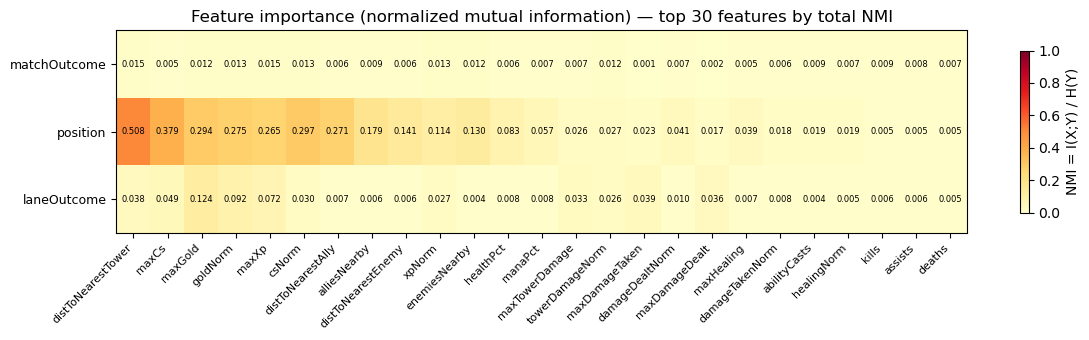

In [5]:
mi_cols      = [c for c in df_agg.columns if c.endswith('_mi') and '_mi_mean' not in c]
target_names = [c.replace('_mi', '') for c in mi_cols]

df_plot = df_agg.copy()
df_plot['total'] = df_plot[mi_cols].sum(axis=1)
df_plot = df_plot.sort_values('total', ascending=False).head(30)

matrix      = df_plot[mi_cols].values.T   # (n_targets, n_features) — already NMI in [0,1]
feat_labels = df_plot['feature'].tolist()

fig, ax = plt.subplots(figsize=(max(12, len(feat_labels) * 0.45), 3.5))
im = ax.imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(len(feat_labels)))
ax.set_xticklabels(feat_labels, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(target_names)))
ax.set_yticklabels(target_names, fontsize=9)
for i in range(len(target_names)):
    for j in range(len(feat_labels)):
        ax.text(j, i, f'{matrix[i, j]:.3f}', ha='center', va='center',
                fontsize=6, color='black' if matrix[i, j] < 0.6 else 'white')
plt.colorbar(im, ax=ax, label='NMI = I(X;Y) / H(Y)', shrink=0.8)
ax.set_title('Feature importance (normalized mutual information) — top 30 features by total NMI')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Ranked tables per target

For time series features, `best_step` is the 15-second interval (0–39) with the highest MI — multiply by 15 for seconds into the game.

In [6]:
for target in TARGETS:
    mi_col = f'{target}_mi'
    if mi_col not in df_agg.columns:
        continue

    ranked = (
        df_agg[['feature', 'is_timeseries', 'best_minute', mi_col]]
        .rename(columns={'best_minute': 'best_step', mi_col: 'MI'})
        .sort_values('MI', ascending=False)
        .head(TOP_N)
        .reset_index(drop=True)
    )
    ranked.index += 1
    ranked['best_step'] = ranked.apply(
        lambda r: f'step {int(r.best_step)} ({int(r.best_step)*15}s)'
                  if r.is_timeseries and pd.notna(r.best_step) else 'scalar',
        axis=1
    )
    ranked = ranked.drop(columns='is_timeseries')

    print(f'\n── Top {TOP_N} features → {target} ──')
    display(
        ranked.style
        .format({'MI': '{:.4f}'})
        .bar(subset='MI', color='#5b9bd5', vmin=0)
    )


── Top 15 features → matchOutcome ──


,feature,best_step,MI
1,maxXp,scalar,0.0148
2,distToNearestTower,step 4 (60s),0.0146
3,goldNorm,step 0 (0s),0.0135
4,csNorm,step 4 (60s),0.0127
5,xpNorm,step 5 (75s),0.0126
6,enemiesNearby,step 4 (60s),0.0124
7,towerDamageNorm,step 38 (570s),0.0124
8,maxGold,scalar,0.0119
9,alliesNearby,step 6 (90s),0.0095
10,abilityCasts,step 5 (75s),0.0093



── Top 15 features → position ──


,feature,best_step,MI
1,distToNearestTower,step 4 (60s),0.5085
2,maxCs,scalar,0.3795
3,csNorm,step 4 (60s),0.2972
4,maxGold,scalar,0.2936
5,goldNorm,step 0 (0s),0.2747
6,distToNearestAlly,step 7 (105s),0.2714
7,maxXp,scalar,0.2650
8,alliesNearby,step 6 (90s),0.1789
9,distToNearestEnemy,step 1 (15s),0.1410
10,enemiesNearby,step 4 (60s),0.1298



── Top 15 features → laneOutcome ──


,feature,best_step,MI
1,maxGold,scalar,0.1237
2,goldNorm,step 0 (0s),0.0919
3,maxXp,scalar,0.0717
4,maxCs,scalar,0.0489
5,maxDamageTaken,scalar,0.0394
6,distToNearestTower,step 4 (60s),0.0377
7,maxDamageDealt,scalar,0.0359
8,maxTowerDamage,scalar,0.0332
9,csNorm,step 4 (60s),0.0298
10,xpNorm,step 5 (75s),0.0265


## MI profile over time — top features

How does predictive power evolve across the laning phase? Features that peak late suggest the outcome is only apparent once the lane is resolved.

## Raw feature classifiers

Logistic regression and XGBoost trained directly on the raw features (same train/test split and classifier configs as `embedding_classifier.py`). This gives a baseline to compare against the SimCLR embedding classifiers — any accuracy gain from the embeddings reflects what the encoder learned beyond what the raw features already contain.

summary = run_raw_feature_classifiers(df, out_dir=FIGURES_DIR)
display(summary.pivot(index='target', columns='model', values='accuracy').round(4))

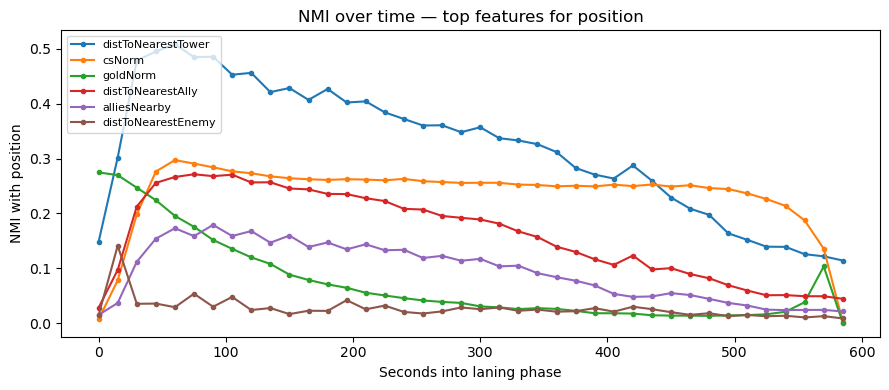

In [8]:
TARGET_FOR_PROFILE = 'position'   # change to 'matchOutcome' or 'laneOutcome'
TOP_TS_FEATURES    = 6
mi_col             = f'{TARGET_FOR_PROFILE}_mi'

top_bases = (
    df_agg[df_agg['is_timeseries'] == True]
    .sort_values(mi_col, ascending=False)
    .head(TOP_TS_FEATURES)['feature']
    .tolist()
)

fig, ax = plt.subplots(figsize=(9, 4))
for base in top_bases:
    rows = df_mi[df_mi['base_feature'] == base].sort_values('minute')
    ax.plot(rows['minute'] * 15, rows[mi_col], marker='o', markersize=3, label=base)

ax.set_xlabel('Seconds into laning phase')
ax.set_ylabel(f'NMI with {TARGET_FOR_PROFILE}')
ax.set_title(f'NMI over time — top features for {TARGET_FOR_PROFILE}')
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / f'mi_over_time_{TARGET_FOR_PROFILE}.png', dpi=150, bbox_inches='tight')
plt.show()

## Time series curves by hero

Individual curves (transparent) with mean curve overlaid (red). Useful for spotting whether a feature has a consistent shape per hero or high variance.

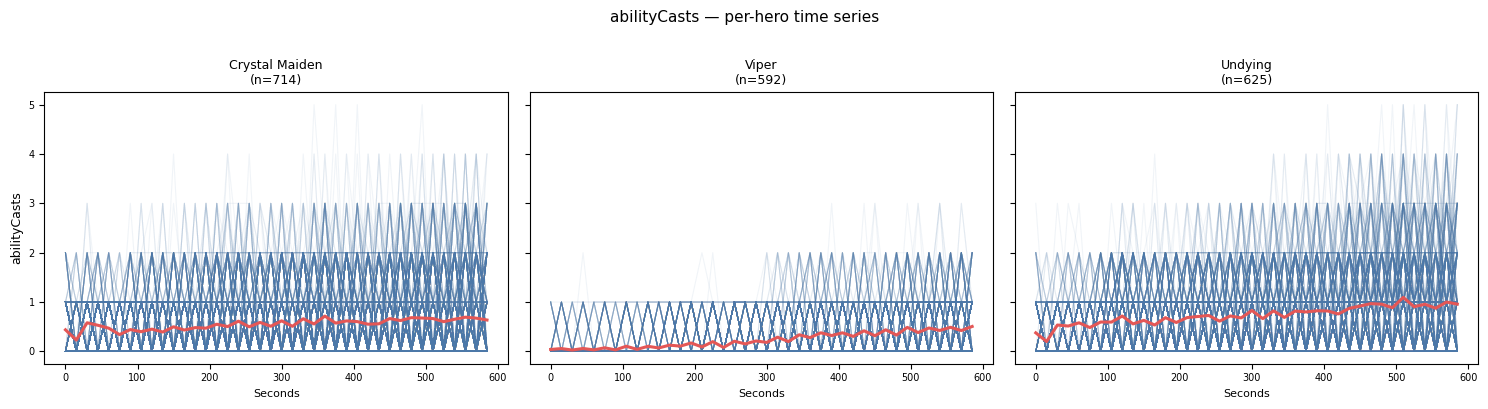

In [32]:
heroes  = ['Crystal Maiden', 'Viper', 'Undying']
feature = 'damageDealtNorm'   # any base time series name, e.g. 'distToNearestTower', 'xpNorm'
# feature = 'manaPct'
# feature = 'healthPct'
feature = 'abilityCasts'
plot_timeseries_by_hero(df, feature, heroes)